In [1]:
import numpy as np
SEED = 7
np.random.seed(SEED) 

In [2]:
import warnings
warnings.filterwarnings("ignore") 

In [3]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [4]:
import kagglehub
path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")

print("Path to dataset files:", path) 

Path to dataset files: C:\Users\manis\.cache\kagglehub\datasets\chethuhn\network-intrusion-dataset\versions\1


In [5]:
import os
path = r"C:\Users\manis\.cache\kagglehub\datasets\chethuhn\network-intrusion-dataset\versions\1"
os.listdir(path) 

['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
 'Friday-WorkingHours-Morning.pcap_ISCX.csv',
 'Monday-WorkingHours.pcap_ISCX.csv',
 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
 'Tuesday-WorkingHours.pcap_ISCX.csv',
 'Wednesday-workingHours.pcap_ISCX.csv']

In [6]:
import pandas as pd

df1 = pd.read_csv(os.path.join(path, "Monday-WorkingHours.pcap_ISCX.csv"))
df2 = pd.read_csv(os.path.join(path,"Tuesday-WorkingHours.pcap_ISCX.csv" ))
df3 = pd.read_csv(os.path.join(path, 'Wednesday-workingHours.pcap_ISCX.csv'))
df4 = pd.read_csv(os.path.join(path, 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'))
df5 = pd.read_csv(os.path.join(path, 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv' ))
df6 = pd.read_csv(os.path.join(path, 'Friday-WorkingHours-Morning.pcap_ISCX.csv' ))
df7 = pd.read_csv(os.path.join(path, 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'))
df8 = pd.read_csv(os.path.join(path, 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'))
df1.head() 

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [7]:
data_list = [df1, df2, df3, df4, df5, df6, df7, df8]

print('Data dimensions: ')
for i, data in enumerate(data_list, start = 1):
  rows, cols = data.shape
  print(f'Data{i} -> {rows} rows, {cols} columns') 

Data dimensions: 
Data1 -> 529918 rows, 79 columns
Data2 -> 445909 rows, 79 columns
Data3 -> 692703 rows, 79 columns
Data4 -> 170366 rows, 79 columns
Data5 -> 288602 rows, 79 columns
Data6 -> 191033 rows, 79 columns
Data7 -> 225745 rows, 79 columns
Data8 -> 286467 rows, 79 columns


In [8]:
data = pd.concat(data_list)
rows, cols = data.shape

print('New dimension:')
print(f'Number of rows: {rows}')
print(f'Number of columns: {cols}')
print(f'Total cells: {rows * cols}')

New dimension:
Number of rows: 2830743
Number of columns: 79
Total cells: 223628697


In [9]:
# Deleting dataframes after concating to save memory
for d in data_list: del d 

In [10]:
data.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [11]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 2830743 entries, 0 to 286466
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max               

In [12]:
data.columns = data.columns.str.strip().str.lower() 

In [13]:
value_counts = data['label'].value_counts()
percentages = data['label'].value_counts(normalize=True) * 100

pd.DataFrame({'Count': value_counts, 'Percentage': percentages.round(2)}) 

,Count,Percentage
label,,
BENIGN,2273097,80.30
DoS Hulk,231073,8.16
PortScan,158930,5.61
DDoS,128027,4.52
DoS GoldenEye,10293,0.36
FTP-Patator,7938,0.28
SSH-Patator,5897,0.21
DoS slowloris,5796,0.20
DoS Slowhttptest,5499,0.19


In [14]:
data.columns

Index(['destination port', 'flow duration', 'total fwd packets',
       'total backward packets', 'total length of fwd packets',
       'total length of bwd packets', 'fwd packet length max',
       'fwd packet length min', 'fwd packet length mean',
       'fwd packet length std', 'bwd packet length max',
       'bwd packet length min', 'bwd packet length mean',
       'bwd packet length std', 'flow bytes/s', 'flow packets/s',
       'flow iat mean', 'flow iat std', 'flow iat max', 'flow iat min',
       'fwd iat total', 'fwd iat mean', 'fwd iat std', 'fwd iat max',
       'fwd iat min', 'bwd iat total', 'bwd iat mean', 'bwd iat std',
       'bwd iat max', 'bwd iat min', 'fwd psh flags', 'bwd psh flags',
       'fwd urg flags', 'bwd urg flags', 'fwd header length',
       'bwd header length', 'fwd packets/s', 'bwd packets/s',
       'min packet length', 'max packet length', 'packet length mean',
       'packet length std', 'packet length variance', 'fin flag count',
       'syn flag co

In [15]:
# Data Cleaning

# Total duplicates in the data
dups = data[data.duplicated()]
print(f'Number of duplicates: {len(dups)}') 

Number of duplicates: 308381


In [16]:
# Dropping the duplicates 
data.drop_duplicates(inplace = True) 
data.shape 

(2522362, 79)

In [17]:
# Finding the missing values in the dataset 
missing_val = data.isna().sum()
print(missing_val.loc[missing_val > 0]) 

flow bytes/s    353
dtype: int64


In [18]:
# Checking for infinity values
numeric_cols = data.select_dtypes(include = np.number).columns
inf_count = np.isinf(data[numeric_cols]).sum()
print(inf_count[inf_count > 0]) 

flow bytes/s      1211
flow packets/s    1564
dtype: int64


In [19]:
# Replacing any infinite values (positive or negative) with NaN (not a number)
# Why it's the best to replace infinities with NaNs
# --> So, that we can handle those as missing values 
print(f'Initial missing values: {data.isna().sum().sum()}')

data.replace([np.inf, -np.inf], np.nan, inplace = True)

print(f'Missing values after processing infinite values: {data.isna().sum().sum()}')  

Initial missing values: 353
Missing values after processing infinite values: 3128


In [20]:
missing = data.isna().sum() 
print(missing.loc[missing > 0]) 

flow bytes/s      1564
flow packets/s    1564
dtype: int64


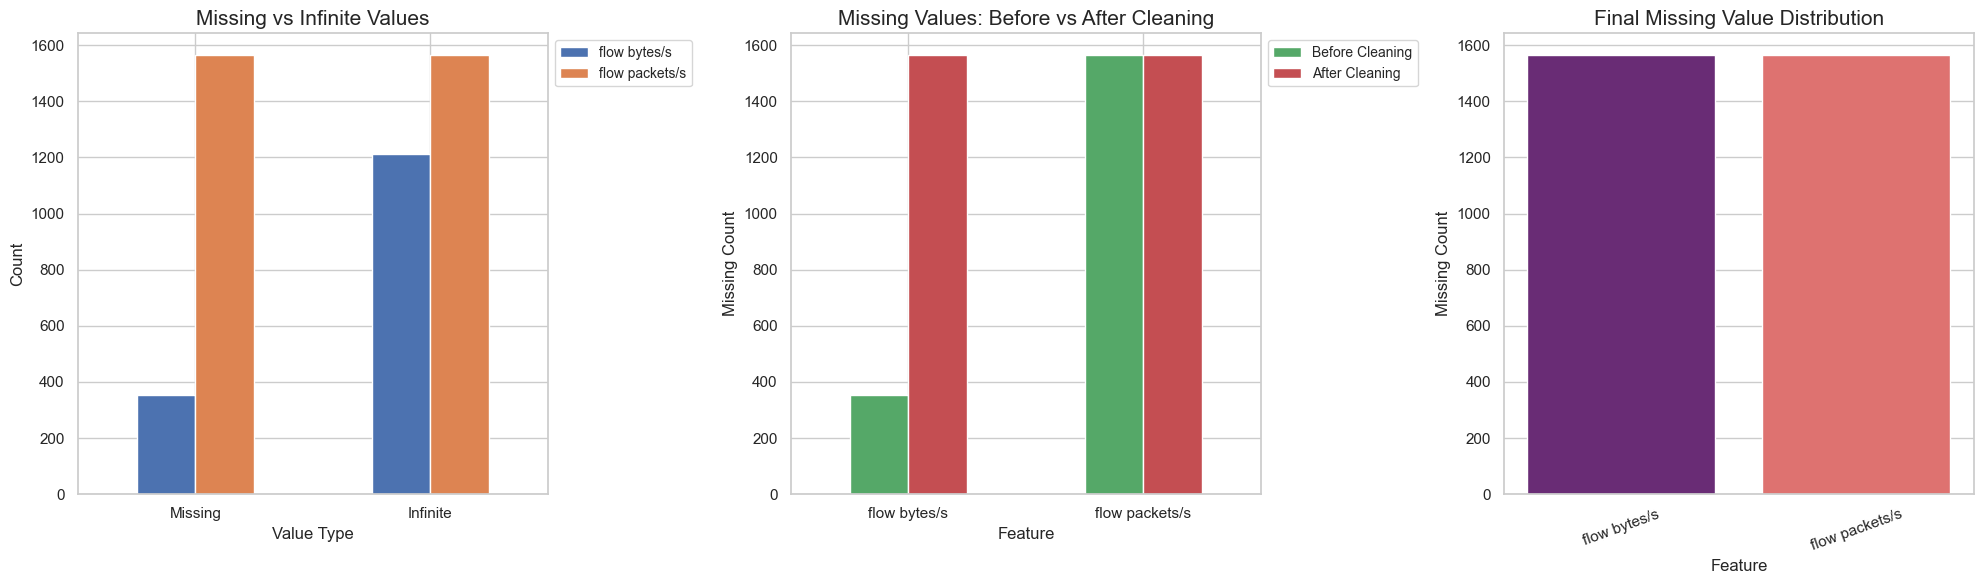

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")

# ----------- DATA -----------
missing_before = {"flow bytes/s": 353, "flow packets/s": 1564}
inf_values = {"flow bytes/s": 1211, "flow packets/s": 1564}
missing_after = {"flow bytes/s": 1564, "flow packets/s": 1564}

df_missing_vs_inf = pd.DataFrame({
    "Missing": missing_before,
    "Infinite": inf_values
})

df_before_after = pd.DataFrame({
    "Before Cleaning": missing_before,
    "After Cleaning": missing_after
})

df_final = pd.Series(missing_after)
# ----------------------------

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Subplot 1: Missing vs Infinite ---
df_missing_vs_inf.T.plot(kind="bar", ax=axes[0],
                         color=["#4C72B0", "#DD8452"])
axes[0].set_title("Missing vs Infinite Values", fontsize=15)
axes[0].set_xlabel("Value Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=10, loc='best', bbox_to_anchor=(1, 1)) 

# --- Subplot 2: Before vs After cleaning ---
df_before_after.plot(kind="bar", ax=axes[1],
                     color=["#55A868", "#C44E52"])
axes[1].set_title("Missing Values: Before vs After Cleaning", fontsize=15)
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("Missing Count")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=10, loc='best', bbox_to_anchor=(1, 1))


# --- Subplot 3: Final Missing Value Distribution ---
sns.barplot(x=df_final.index, y=df_final.values,
            palette="magma", ax=axes[2])
axes[2].set_title("Final Missing Value Distribution", fontsize=15)
axes[2].set_xlabel("Feature")
axes[2].set_ylabel("Missing Count")
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show() 


In [22]:
# Why filling with median is best in this case? 
med_flow_bytes = data['flow bytes/s'].median()
med_flow_packets = data['flow packets/s'].median()

print('Median of Flow Bytes/s: ', med_flow_bytes)
print('Median of Flow Packets/s: ', med_flow_packets) 

Median of Flow Bytes/s:  3715.0378579999997
Median of Flow Packets/s:  69.742244285


In [23]:
# Filling missing values with median
data['flow bytes/s'].fillna(med_flow_bytes, inplace = True)
data['flow packets/s'].fillna(med_flow_packets, inplace = True) 

In [24]:
print('Number of \'Flow Bytes/s\' missing values:', data['flow bytes/s'].isna().sum())
print('Number of \'Flow Packets/s\' missing values:', data['flow packets/s'].isna().sum()) 

Number of 'Flow Bytes/s' missing values: 0
Number of 'Flow Packets/s' missing values: 0


In [25]:
# Analyzing patterns Using Visualizations
data['label'].unique() 

array(['BENIGN', 'FTP-Patator', 'SSH-Patator', 'DoS slowloris',
       'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye', 'Heartbleed',
       'Web Attack � Brute Force', 'Web Attack � XSS',
       'Web Attack � Sql Injection', 'Infiltration', 'Bot', 'DDoS',
       'PortScan'], dtype=object)

In [26]:
data['label'].value_counts() 

label
BENIGN                        2096484
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [27]:
# Creating a dictionary that maps each label to its attack type
attack_map = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'PortScan': 'Port Scan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bot',
    'Web Attack � Brute Force': 'Web Attack',
    'Web Attack � XSS': 'Web Attack',
    'Web Attack � Sql Injection': 'Web Attack',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed'
} 
# Creating a new column 'Attack Type' in the DataFrame based on the attack_map dictionary
data['attack type'] = data['label'].map(attack_map) 

In [28]:
data['attack type'].value_counts() 

attack type
BENIGN          2096484
DoS              193748
DDoS             128016
Port Scan         90819
Brute Force        9152
Web Attack         2143
Bot                1953
Infiltration         36
Heartbleed           11
Name: count, dtype: int64

In [29]:
data.drop('label', axis = 1, inplace = True) 

In [30]:
print(data.columns) 

Index(['destination port', 'flow duration', 'total fwd packets',
       'total backward packets', 'total length of fwd packets',
       'total length of bwd packets', 'fwd packet length max',
       'fwd packet length min', 'fwd packet length mean',
       'fwd packet length std', 'bwd packet length max',
       'bwd packet length min', 'bwd packet length mean',
       'bwd packet length std', 'flow bytes/s', 'flow packets/s',
       'flow iat mean', 'flow iat std', 'flow iat max', 'flow iat min',
       'fwd iat total', 'fwd iat mean', 'fwd iat std', 'fwd iat max',
       'fwd iat min', 'bwd iat total', 'bwd iat mean', 'bwd iat std',
       'bwd iat max', 'bwd iat min', 'fwd psh flags', 'bwd psh flags',
       'fwd urg flags', 'bwd urg flags', 'fwd header length',
       'bwd header length', 'fwd packets/s', 'bwd packets/s',
       'min packet length', 'max packet length', 'packet length mean',
       'packet length std', 'packet length variance', 'fin flag count',
       'syn flag co

In [31]:
# Why LabelEncoder is best in this case? 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['attack number'] = le.fit_transform(data['attack type'])

print(data['attack number'].unique())  

[0 2 4 5 8 6 1 3 7]


In [32]:
# Printing corresponding attack type for each encoded value
encoded_values = data['attack number'].unique()
for val in sorted(encoded_values):
    print(f"{val}: {le.inverse_transform([val])[0]}")  

0: BENIGN
1: Bot
2: Brute Force
3: DDoS
4: DoS
5: Heartbleed
6: Infiltration
7: Port Scan
8: Web Attack


In [33]:
# Some steps for feature selection 
corr = data.corr(numeric_only = True).round(2)
corr 

,destination port,flow duration,total fwd packets,total backward packets,total length of fwd packets,total length of bwd packets,fwd packet length max,fwd packet length min,fwd packet length mean,fwd packet length std,...,min_seg_size_forward,active mean,active std,active max,active min,idle mean,idle std,idle max,idle min,attack number
destination port,1.00,-0.17,-0.00,-0.00,0.01,-0.00,0.09,-0.05,0.14,0.12,...,0.0,-0.04,-0.05,-0.06,-0.03,-0.13,0.01,-0.12,-0.13,-0.13
flow duration,-0.17,1.00,0.02,0.02,0.06,0.02,0.26,-0.12,0.13,0.22,...,-0.0,0.18,0.24,0.29,0.12,0.76,0.24,0.78,0.73,0.21
total fwd packets,-0.00,0.02,1.00,1.00,0.37,1.00,0.01,-0.00,-0.00,0.00,...,-0.0,0.04,0.01,0.03,0.04,0.00,0.00,0.00,0.00,-0.00
total backward packets,-0.00,0.02,1.00,1.00,0.36,0.99,0.01,-0.00,-0.00,0.00,...,0.0,0.04,0.01,0.03,0.04,0.00,0.00,0.00,0.00,-0.00
total length of fwd packets,0.01,0.06,0.37,0.36,1.00,0.35,0.20,-0.00,0.19,0.16,...,-0.0,0.10,0.10,0.13,0.07,0.02,0.03,0.02,0.02,-0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
idle mean,-0.13,0.76,0.00,0.00,0.02,0.00,0.17,-0.08,0.12,0.17,...,-0.0,0.12,0.03,0.08,0.11,1.00,0.15,0.99,0.99,0.38
idle std,0.01,0.24,0.00,0.00,0.03,0.00,0.18,-0.03,0.18,0.19,...,-0.0,0.07,0.08,0.07,0.04,0.15,1.00,0.28,0.01,0.08
idle max,-0.12,0.78,0.00,0.00,0.02,0.00,0.19,-0.08,0.14,0.19,...,-0.0,0.13,0.05,0.10,0.12,0.99,0.28,1.00,0.96,0.38
idle min,-0.13,0.73,0.00,0.00,0.02,0.00,0.15,-0.07,0.10,0.15,...,-0.0,0.11,0.02,0.07,0.11,0.99,0.01,0.96,1.00,0.38


In [34]:

'''# Positive correlation features for 'attack number'
pos_corr_features = corr['attack number'][(corr['attack number'] > 0) & (corr['attack number'] < 1)].index.tolist()

print("Features with positive correlation with 'label':\n")
for i, feature in enumerate(pos_corr_features, start = 1):
    corr_value = corr.loc[feature, 'attack number']
    print('{:<3} {:<24} :{}'.format(f'{i}.', feature, corr_value)) 
'''

'# Positive correlation features for \'attack number\'\npos_corr_features = corr[\'attack number\'][(corr[\'attack number\'] > 0) & (corr[\'attack number\'] < 1)].index.tolist()\n\nprint("Features with positive correlation with \'label\':\n")\nfor i, feature in enumerate(pos_corr_features, start = 1):\n    corr_value = corr.loc[feature, \'attack number\']\n    print(\'{:<3} {:<24} :{}\'.format(f\'{i}.\', feature, corr_value)) \n'

In [35]:
'''print(f'Number of considerable important features: {len(pos_corr_features)}') ''' 

"print(f'Number of considerable important features: {len(pos_corr_features)}') "

In [36]:
# Checking for columns with zero standard deviation (the blank squares in the heatmap)
std = data.std(numeric_only = True)
zero_std_cols = std[std == 0].index.tolist()
zero_std_cols 

['bwd psh flags',
 'bwd urg flags',
 'fwd avg bytes/bulk',
 'fwd avg packets/bulk',
 'fwd avg bulk rate',
 'bwd avg bytes/bulk',
 'bwd avg packets/bulk',
 'bwd avg bulk rate']

In [37]:
'''If you train on th entire dataset, the model will be flooded by normal samples and might ignore anomalies. So engineers sample:

Fewer normal samples (downsampling)
All or more anomalous samples (upsampling)
This creates a balanced training set where the model can actually learn what anomalies look like.
If my 20% random sample covers the same statistical patterns as the full 100%, my model can learn the same thing — faster.
Sampling doesn’t mean throwing data away but it means using a smaller, representative part of data efficiently.
'''

'If you train on th entire dataset, the model will be flooded by normal samples and might ignore anomalies. So engineers sample:\n\nFewer normal samples (downsampling)\nAll or more anomalous samples (upsampling)\nThis creates a balanced training set where the model can actually learn what anomalies look like.\nIf my 20% random sample covers the same statistical patterns as the full 100%, my model can learn the same thing — faster.\nSampling doesn’t mean throwing data away but it means using a smaller, representative part of data efficiently.\n'

In [38]:
data.drop('attack number', axis = 1, inplace = True)  

In [39]:
'''import seaborn as sns
import matplotlib.pyplot as plt
# Different 'Attack Type' in the main dataset excluding 'BENIGN'
attacks = data.loc[data['attack type'] != 'BENIGN']

plt.figure(figsize = (10, 6))
ax = sns.countplot(x = 'attack type', data = attacks, palette = 'pastel', order = attacks['attack type'].value_counts().index)
plt.title('Types of attacks')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation = 90)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2, p.get_height() + 1000), ha = 'center')

plt.show() 
'''

"import seaborn as sns\nimport matplotlib.pyplot as plt\n# Different 'Attack Type' in the main dataset excluding 'BENIGN'\nattacks = data.loc[data['attack type'] != 'BENIGN']\n\nplt.figure(figsize = (10, 6))\nax = sns.countplot(x = 'attack type', data = attacks, palette = 'pastel', order = attacks['attack type'].value_counts().index)\nplt.title('Types of attacks')\nplt.xlabel('Attack Type')\nplt.ylabel('Count')\nplt.xticks(rotation = 90)\n\nfor p in ax.patches:\n    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2, p.get_height() + 1000), ha = 'center')\n\nplt.show() \n"

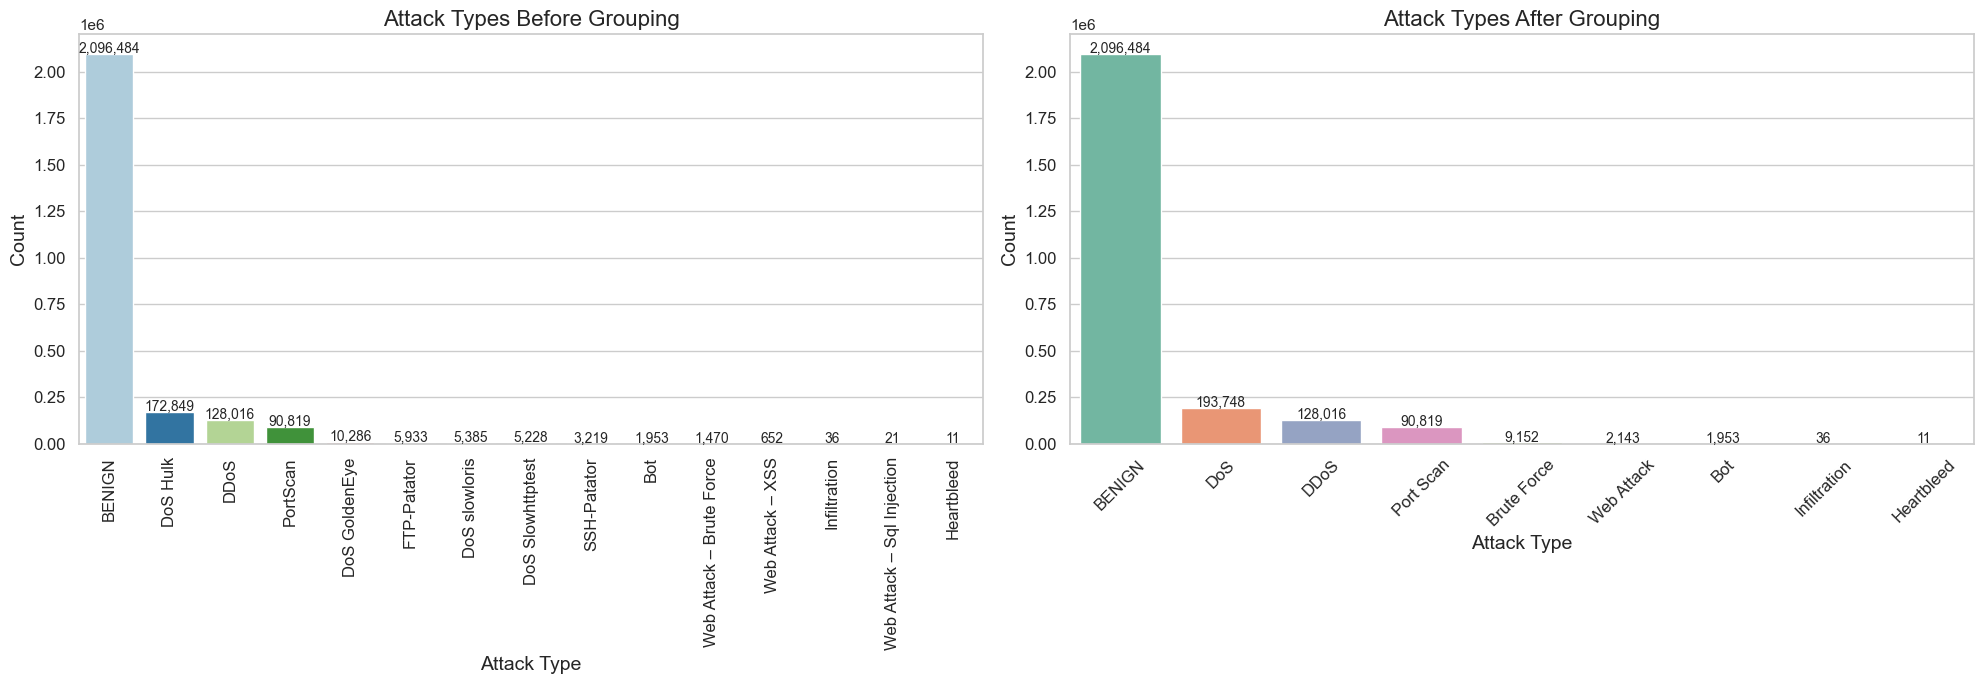

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")

# ---------------- DATA -----------------
# Attack counts before grouping
attack_before = pd.Series({
    "BENIGN": 2096484,
    "DoS Hulk": 172849,
    "DDoS": 128016,
    "PortScan": 90819,
    "DoS GoldenEye": 10286,
    "FTP-Patator": 5933,
    "DoS slowloris": 5385,
    "DoS Slowhttptest": 5228,
    "SSH-Patator": 3219,
    "Bot": 1953,
    "Web Attack – Brute Force": 1470,
    "Web Attack – XSS": 652,
    "Infiltration": 36,
    "Web Attack – Sql Injection": 21,
    "Heartbleed": 11
})

# Attack counts after grouping
attack_after = pd.Series({
    "BENIGN": 2096484,
    "DoS": 193748,
    "DDoS": 128016,
    "Port Scan": 90819,
    "Brute Force": 9152,
    "Web Attack": 2143,
    "Bot": 1953,
    "Infiltration": 36,
    "Heartbleed": 11
})
# ---------------------------------------

# ---------------- PLOT -----------------
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- Before Grouping ---
palette_before = sns.color_palette("Paired", n_colors=len(attack_before))
ax1 = sns.barplot(
    x=attack_before.index,
    y=attack_before.values,
    palette=palette_before,
    ax=axes[0]
)
axes[0].set_title("Attack Types Before Grouping", fontsize=16)
axes[0].set_xlabel("Attack Type", fontsize=14)
axes[0].set_ylabel("Count", fontsize=14)
axes[0].tick_params(axis='x', rotation=90, labelsize=12)
axes[0].tick_params(axis='y', labelsize=12)

# Add counts on top of bars
for p in ax1.patches:
    ax1.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2, p.get_height() + 5000),
        ha='center', fontsize=10
    )

# --- After Grouping ---
palette_after = sns.color_palette("Set2", n_colors=len(attack_after))
ax2 = sns.barplot(
    x=attack_after.index,
    y=attack_after.values,
    palette=palette_after,
    ax=axes[1]
)
axes[1].set_title("Attack Types After Grouping", fontsize=16)
axes[1].set_xlabel("Attack Type", fontsize=14)
axes[1].set_ylabel("Count", fontsize=14)
axes[1].tick_params(axis='x', rotation=45, labelsize=12)
axes[1].tick_params(axis='y', labelsize=12)

# Add counts on top of bars
for p in ax2.patches:
    ax2.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2, p.get_height() + 5000),
        ha='center', fontsize=10
    )

plt.tight_layout()
plt.show()


In [41]:
data.groupby('attack type').first() 

,destination port,flow duration,total fwd packets,total backward packets,total length of fwd packets,total length of bwd packets,fwd packet length max,fwd packet length min,fwd packet length mean,fwd packet length std,...,act_data_pkt_fwd,min_seg_size_forward,active mean,active std,active max,active min,idle mean,idle std,idle max,idle min
attack type,,,,,,,,,,,,,,,,,,,,,
BENIGN,49188,4,2,0,12,0,6,6,6.000000,0.000000,...,1,20,0.0,0.00000,0,0,0.0,0.00000,0,0
Bot,8080,60202640,9,9,322,256,322,0,35.777778,107.333333,...,1,32,63678.2,22252.53596,103175,50911,10200000.0,34941.27201,10200000,10100000
Brute Force,80,5216127,3,1,0,0,0,0,0.000000,0.000000,...,0,32,0.0,0.00000,0,0,0.0,0.00000,0,0
DDoS,80,1293792,3,7,26,11607,20,0,8.666667,10.263203,...,2,20,0.0,0.00000,0,0,0.0,0.00000,0,0
DoS,80,5169956,8,6,1101,4222,410,0,137.625000,185.758628,...,7,20,0.0,0.00000,0,0,0.0,0.00000,0,0
Heartbleed,444,119302728,2685,1729,8299,7556917,517,0,3.090875,16.858421,...,118,32,2217.0,0.00000,2217,2217,5024984.0,0.00000,5024984,5024984
Infiltration,444,42664070,5,6,141,291,93,0,28.200000,38.861292,...,4,20,0.0,0.00000,0,0,0.0,0.00000,0,0
Port Scan,80,5021059,6,5,703,1414,356,0,117.166667,181.536131,...,2,32,0.0,0.00000,0,0,0.0,0.00000,0,0
Web Attack,80,5185118,7,7,1022,2321,372,0,146.000000,184.078788,...,3,32,0.0,0.00000,0,0,0.0,0.00000,0,0


In [42]:
# For improving performance and reduce memory-related errors
old_memory_usage = data.memory_usage().sum() / 1024 ** 2
print(f'Initial memory usage: {old_memory_usage:.2f} MB')
for col in data.columns:
    col_type = data[col].dtype
    if col_type != object:
        c_min = data[col].min()
        c_max = data[col].max()
        # Downcasting float64 to float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            data[col] = data[col].astype(np.float32)

        # Downcasting int64 to int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            data[col] = data[col].astype(np.int32)

new_memory_usage = data.memory_usage().sum() / 1024 ** 2
print(f"Final memory usage: {new_memory_usage:.2f} MB") 

Initial memory usage: 1539.53 MB
Final memory usage: 808.25 MB


In [43]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 2522362 entries, 0 to 286466
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   destination port             int32  
 1   flow duration                int32  
 2   total fwd packets            int32  
 3   total backward packets       int32  
 4   total length of fwd packets  int32  
 5   total length of bwd packets  int32  
 6   fwd packet length max        int32  
 7   fwd packet length min        int32  
 8   fwd packet length mean       float32
 9   fwd packet length std        float32
 10  bwd packet length max        int32  
 11  bwd packet length min        int32  
 12  bwd packet length mean       float32
 13  bwd packet length std        float32
 14  flow bytes/s                 float32
 15  flow packets/s               float32
 16  flow iat mean                float32
 17  flow iat std                 float32
 18  flow iat max                 int32  
 19  flow i

In [44]:
# Dropping columns with only one unique value or say standard deviation zero
num_unique = data.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index

dropped_cols = one_variable.index
data = data[not_one_variable]

print('Dropped columns:')
dropped_cols  

Dropped columns:


Index(['bwd psh flags', 'bwd urg flags', 'fwd avg bytes/bulk',
       'fwd avg packets/bulk', 'fwd avg bulk rate', 'bwd avg bytes/bulk',
       'bwd avg packets/bulk', 'bwd avg bulk rate'],
      dtype='object')

In [45]:
data.shape

(2522362, 71)

In [46]:
data.columns 

Index(['destination port', 'flow duration', 'total fwd packets',
       'total backward packets', 'total length of fwd packets',
       'total length of bwd packets', 'fwd packet length max',
       'fwd packet length min', 'fwd packet length mean',
       'fwd packet length std', 'bwd packet length max',
       'bwd packet length min', 'bwd packet length mean',
       'bwd packet length std', 'flow bytes/s', 'flow packets/s',
       'flow iat mean', 'flow iat std', 'flow iat max', 'flow iat min',
       'fwd iat total', 'fwd iat mean', 'fwd iat std', 'fwd iat max',
       'fwd iat min', 'bwd iat total', 'bwd iat mean', 'bwd iat std',
       'bwd iat max', 'bwd iat min', 'fwd psh flags', 'fwd urg flags',
       'fwd header length', 'bwd header length', 'fwd packets/s',
       'bwd packets/s', 'min packet length', 'max packet length',
       'packet length mean', 'packet length std', 'packet length variance',
       'fin flag count', 'syn flag count', 'rst flag count', 'psh flag count',

In [47]:
data.describe() 

,destination port,flow duration,total fwd packets,total backward packets,total length of fwd packets,total length of bwd packets,fwd packet length max,fwd packet length min,fwd packet length mean,fwd packet length std,...,act_data_pkt_fwd,min_seg_size_forward,active mean,active std,active max,active min,idle mean,idle std,idle max,idle min
count,2.522362e+06,2.522362e+06,2.522362e+06,2.522362e+06,2.522362e+06,2.522362e+06,2.522362e+06,2.522362e+06,2.522362e+06,2.522362e+06,...,2.522362e+06,2.522362e+06,2.522362e+06,2.522362e+06,2.522362e+06,2.522362e+06,2522362.0,2.522362e+06,2.522362e+06,2.522362e+06
mean,8.704762e+03,1.658132e+07,1.027627e+01,1.156596e+01,6.115751e+02,1.813315e+04,2.310918e+02,1.919464e+01,6.347012e+01,7.727754e+01,...,6.005904e+00,-3.080307e+03,9.152168e+04,4.616312e+04,1.719104e+05,6.542300e+04,9331579.0,5.654434e+05,9.757716e+06,8.887157e+06
std,1.902507e+04,3.522426e+07,7.941738e+02,1.056594e+03,1.058499e+04,2.397434e+06,7.561625e+02,6.079447e+01,1.955015e+02,2.967953e+02,...,6.742059e+02,1.149402e+06,6.864412e+05,4.164568e+05,1.085243e+06,6.109712e+05,24841566.0,4.872678e+06,2.561067e+07,2.457481e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,2.080000e+02,2.000000e+00,1.000000e+00,1.200000e+01,6.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,5.057700e+04,2.000000e+00,2.000000e+00,6.600000e+01,1.550000e+02,4.000000e+01,2.000000e+00,3.611111e+01,0.000000e+00,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,5.329717e+06,6.000000e+00,5.000000e+00,3.320000e+02,9.880000e+02,2.020000e+02,3.700000e+01,5.200000e+01,7.413914e+01,...,3.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,120000000.0,7.690000e+07,1.200000e+08,1.200000e+08


In [48]:
# Why use StandardScalar and not other Scalar? 

# Standardizing the dataset 
from sklearn.preprocessing import StandardScaler

features = data.drop('attack type', axis = 1)
attacks = data['attack type']

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)  

In [49]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(
    n_estimators=200,       # Number of trees
    contamination=0.05,    # % of expected outliers 
    random_state=42
) 

In [50]:
iso.fit(scaled_features) 

IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

In [51]:
data['anomaly'] = iso.predict(scaled_features) 

In [52]:
# Convert -1 to 1 for outliers 
data['is_outlier'] = data['anomaly'].apply(lambda x: 1 if x == -1 else 0)

# -----------------------------
# 5. Show results
# -----------------------------
print(data[['anomaly', 'is_outlier']].head())

# Count outliers
print("Total Outliers:", data['is_outlier'].sum()) 

   anomaly  is_outlier
0        1           0
1        1           0
4        1           0
5        1           0
8        1           0
Total Outliers: 126119


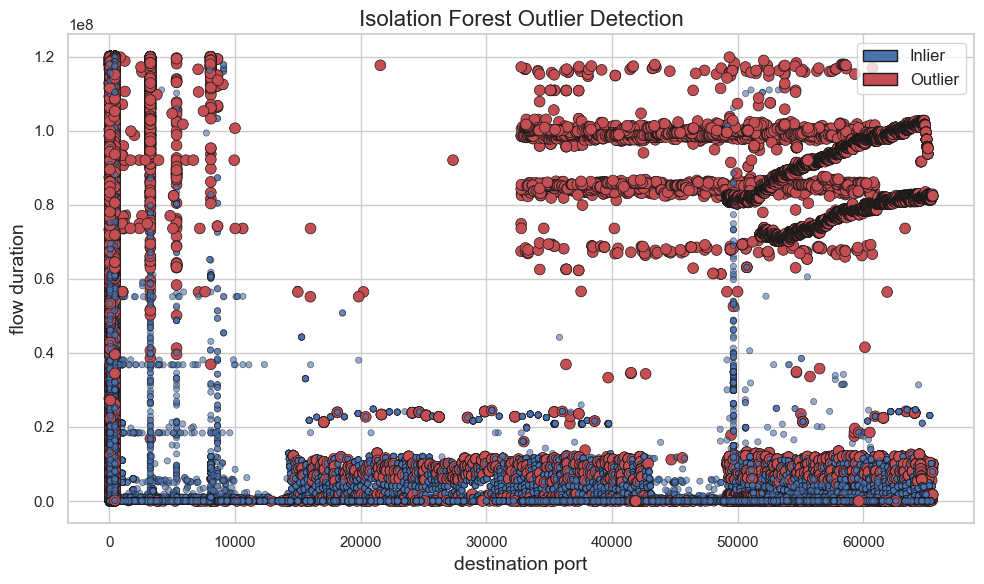

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set(style="whitegrid")

# Extract features
x = data.iloc[:, 0]
y = data.iloc[:, 1]
outlier_flag = data['is_outlier']

# Colors: inliers = blue, outliers = red
colors = ['#4C72B0' if val == 0 else '#C44E52' for val in outlier_flag]
sizes = [20 if val == 0 else 60 for val in outlier_flag]  # bigger size for outliers
alpha = [0.6 if val == 0 else 1.0 for val in outlier_flag]  # more transparent inliers

plt.figure(figsize=(10, 6))
plt.scatter(x, y, c=colors, s=sizes, alpha=alpha, edgecolor='k', linewidth=0.5)

# Labels and title
plt.xlabel(data.columns[0], fontsize=14)
plt.ylabel(data.columns[1], fontsize=14)
plt.title("Isolation Forest Outlier Detection", fontsize=16)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', edgecolor='k', label='Inlier'),
                   Patch(facecolor='#C44E52', edgecolor='k', label='Outlier')]
plt.legend(handles=legend_elements, fontsize=12)

plt.tight_layout()
plt.show()  

In [54]:
'''Most network traffic is normal (violet clusters)

Some points deviate from normal behavior → anomalies (white points)

The dataset has distinct traffic patterns, causing clusters

Some specific port ranges appear extremely active

Flow duration varies widely but forms specific bands
''' 

'Most network traffic is normal (violet clusters)\n\nSome points deviate from normal behavior → anomalies (white points)\n\nThe dataset has distinct traffic patterns, causing clusters\n\nSome specific port ranges appear extremely active\n\nFlow duration varies widely but forms specific bands\n'

In [55]:
data.columns 

Index(['destination port', 'flow duration', 'total fwd packets',
       'total backward packets', 'total length of fwd packets',
       'total length of bwd packets', 'fwd packet length max',
       'fwd packet length min', 'fwd packet length mean',
       'fwd packet length std', 'bwd packet length max',
       'bwd packet length min', 'bwd packet length mean',
       'bwd packet length std', 'flow bytes/s', 'flow packets/s',
       'flow iat mean', 'flow iat std', 'flow iat max', 'flow iat min',
       'fwd iat total', 'fwd iat mean', 'fwd iat std', 'fwd iat max',
       'fwd iat min', 'bwd iat total', 'bwd iat mean', 'bwd iat std',
       'bwd iat max', 'bwd iat min', 'fwd psh flags', 'fwd urg flags',
       'fwd header length', 'bwd header length', 'fwd packets/s',
       'bwd packets/s', 'min packet length', 'max packet length',
       'packet length mean', 'packet length std', 'packet length variance',
       'fin flag count', 'syn flag count', 'rst flag count', 'psh flag count',

In [56]:
data = data.drop(['anomaly', 'is_outlier'], axis=1) 

In [57]:
data.columns

Index(['destination port', 'flow duration', 'total fwd packets',
       'total backward packets', 'total length of fwd packets',
       'total length of bwd packets', 'fwd packet length max',
       'fwd packet length min', 'fwd packet length mean',
       'fwd packet length std', 'bwd packet length max',
       'bwd packet length min', 'bwd packet length mean',
       'bwd packet length std', 'flow bytes/s', 'flow packets/s',
       'flow iat mean', 'flow iat std', 'flow iat max', 'flow iat min',
       'fwd iat total', 'fwd iat mean', 'fwd iat std', 'fwd iat max',
       'fwd iat min', 'bwd iat total', 'bwd iat mean', 'bwd iat std',
       'bwd iat max', 'bwd iat min', 'fwd psh flags', 'fwd urg flags',
       'fwd header length', 'bwd header length', 'fwd packets/s',
       'bwd packets/s', 'min packet length', 'max packet length',
       'packet length mean', 'packet length std', 'packet length variance',
       'fin flag count', 'syn flag count', 'rst flag count', 'psh flag count',

In [58]:
# Why use IncrementPCA? 
from sklearn.decomposition import IncrementalPCA
size = len(features.columns) // 2
ipca = IncrementalPCA(n_components = size, batch_size = 500)
for batch in np.array_split(scaled_features, len(features) // 500):
    ipca.partial_fit(batch)

print(f'information retained: {sum(ipca.explained_variance_ratio_):.2%}') 

information retained: 99.30%


In [59]:
transformed_features = ipca.transform(scaled_features)
new_data = pd.DataFrame(transformed_features, columns = [f'PC{i+1}' for i in range(size)])
new_data['attack type'] = attacks.values
print(len(transformed_features), len(attacks))   

2522362 2522362


In [60]:
# Creating a balanced dataset for Binary Classification
normal_traffic = new_data.loc[new_data['attack type'] == 'BENIGN']
intrusions = new_data.loc[new_data['attack type'] != 'BENIGN']

normal_traffic = normal_traffic.sample(n = len(intrusions), replace = False)

ids_data = pd.concat([intrusions, normal_traffic])
ids_data['attack type'] = np.where((ids_data['attack type'] == 'BENIGN'), 0, 1)
bc_data = ids_data.sample(n = 20000) 

print(bc_data['attack type'].value_counts()) 

attack type
1    10034
0     9966
Name: count, dtype: int64


In [61]:
bc_data 

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,attack type
1080722,9.358975,-0.305021,-1.573795,-2.337903,2.164631,-0.448710,-0.095588,-0.999269,0.531986,1.180831,...,0.002886,-0.206970,0.061554,0.263916,0.498915,-0.060638,0.000622,-0.618587,0.151135,1
1171734,6.377827,-0.747452,4.507055,-0.135987,2.131633,0.543314,-0.148042,-3.242425,-0.612370,1.597544,...,1.214270,0.811346,0.428905,0.354355,0.425527,-0.047228,-0.002988,1.103984,-0.203426,1
2385241,-1.989040,-0.039763,0.196994,-0.669131,-1.244578,-0.916119,-0.069794,-0.626994,0.842700,-0.256847,...,0.035178,-0.006665,-0.042091,0.041809,0.021472,-0.001749,0.000467,-0.009116,-0.010473,0
2208085,9.316547,0.566182,1.136256,13.518495,-0.055885,-5.669852,-0.127834,-3.038099,-2.264454,2.124777,...,-0.267683,0.012553,0.412491,-0.305303,-0.732627,-0.001900,-0.001185,-0.498448,0.480757,0
1690488,-2.000448,-0.039795,0.208647,-0.598662,-1.022022,-0.650070,-0.050272,-0.544500,0.528242,-0.183290,...,-0.047342,-0.132341,-0.132318,0.199306,-0.069502,-0.001290,0.001431,-0.008187,-0.003693,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41104,-1.435480,-0.030843,0.157726,-0.102440,-0.297557,1.293237,0.126034,0.601579,-1.769268,0.050926,...,-0.561051,-0.179827,0.605524,-0.104463,0.200863,-0.023876,0.000268,0.311314,-0.107408,0
372913,-2.254700,-0.049532,0.471577,0.393422,2.053292,-0.128253,-0.015781,-0.765373,-0.875222,2.607044,...,-0.041369,0.441586,0.799037,0.147428,-0.012341,-0.013193,0.001682,0.007861,-0.001199,0
2371484,-0.456228,0.145981,-1.596133,-0.218692,-0.532865,0.576624,0.099416,1.139001,-0.810584,-0.480135,...,-0.562131,0.249772,0.803514,-0.371244,-0.286511,0.005907,0.001379,-0.079888,0.100445,0
361655,-2.274710,-0.047566,0.479531,0.487887,2.191754,-0.144681,-0.015137,-0.775212,-0.930836,2.751492,...,-0.033428,0.920615,0.772955,0.292808,0.061907,-0.019227,0.001952,0.004674,-0.007944,0


In [62]:
from pycaret.classification import * 
target = 'attack type'

# Setup PyCaret
s2 = setup(
    data=bc_data,
    target=target,
    session_id=42,
    preprocess=False,
    log_experiment=False,
    use_gpu=False,
    fold_strategy='stratifiedkfold'
) 

,Description,Value
0,Session id,42
1,Target,attack type
2,Target type,Binary
3,Original data shape,"(20000, 36)"
4,Transformed data shape,"(20000, 36)"
5,Transformed train set shape,"(14000, 36)"
6,Transformed test set shape,"(6000, 36)"
7,Numeric features,35


In [73]:
top8_models = compare_models(sort='F1', n_select=8) 
top8_models 

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.9924,0.9993,0.9919,0.9929,0.9924,0.9847,0.9847,8.5780
xgboost,Extreme Gradient Boosting,0.9921,0.9994,0.9922,0.9920,0.9921,0.9841,0.9842,0.1730
lightgbm,Light Gradient Boosting Machine,0.9917,0.9994,0.9907,0.9927,0.9917,0.9834,0.9834,0.2610
et,Extra Trees Classifier,0.9914,0.9990,0.9902,0.9927,0.9914,0.9829,0.9829,0.1600
rf,Random Forest Classifier,0.9906,0.9989,0.9899,0.9914,0.9907,0.9813,0.9813,0.6590
dt,Decision Tree Classifier,0.9848,0.9848,0.9876,0.9822,0.9849,0.9696,0.9696,0.1380
gbc,Gradient Boosting Classifier,0.9814,0.9973,0.9835,0.9796,0.9815,0.9629,0.9629,2.9560
knn,K Neighbors Classifier,0.9786,0.9923,0.9845,0.9731,0.9788,0.9571,0.9572,0.7900
ada,Ada Boost Classifier,0.9621,0.9937,0.9671,0.9578,0.9624,0.9241,0.9243,0.5290
lr,Logistic Regression,0.9246,0.9781,0.9618,0.8956,0.9275,0.8491,0.8515,1.1010


 XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device='cpu', early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=-1, num_parallel_tree=None, ...),
 LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
                importance_type='split', learning_rate=0.1, max_depth=-1,
                min_child_samples=20, min_child_weight=0.001, min_split

In [64]:
# XGBOOST IS THE BEST MODEl, THEN LIGHTBGM AND EXTRA TREES CLASSIFIER

In [68]:
evaluate_model(top8_models) 

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
# Preparing data for multiclass classification 
new_data['attack type'].value_counts() 

In [ ]:

class_counts = new_data['attack type'].value_counts()
selected_classes = class_counts[class_counts > 1950]
class_names = selected_classes.index
selected = new_data[new_data['attack type'].isin(class_names)]

dfs = []
for name in class_names:
  df = selected[selected['attack type'] == name]
  if len(df) > 2500:
    df = df.sample(n = 8000, random_state = 0)

  dfs.append(df)

df = pd.concat(dfs, ignore_index = True)
df['attack type'].value_counts()  

In [ ]:
from imblearn.over_sampling import SMOTE

X = df.drop('attack type', axis=1)
y = df['attack type']

smote = SMOTE(sampling_strategy='auto', random_state=0)
X_upsampled, y_upsampled = smote.fit_resample(X, y)

blnc_data = pd.DataFrame(X_upsampled)
blnc_data['attack type'] = y_upsampled
blnc_data = blnc_data.sample(frac=1)

blnc_data['attack type'].value_counts() 

In [ ]:
# Setup PyCaret
s2 = setup(
    data=blnc_data,
    target=target,
    session_id=42,
    preprocess=False,
    log_experiment=False,
    use_gpu=False,
    fold_strategy='stratifiedkfold'
) 

In [ ]:
best_model2 = compare_models(sort='F1', n_select=8)
print(best_model2)   

In [ ]:
evaluate_model(best_model2[4]) 

In [ ]:
evaluate_models(top8_models) 

In [ ]:
evaluate_model(best_model2[3])        